In [3]:
import json, random
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train_uni_8.jsonl"
jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train.jsonl"
rows = [json.loads(l) for l in open(jsonl_path)]
print(f"Total rows: {len(rows)}")

Total rows: 96764


## random select an item to illustrate

Query: find the box that is closer to the radiator
Images: 8
Boxes: [[489.9422886277581, 457.5113737407757, 518.0, 518.0], None, [190.79018176343226, 346.1703010170827, 255.79964872779948, 445.69085786826656], [48.23486433331735, 409.05761889466396, 130.12423772218855, 518.0], None, [348.36770964272296, 329.2474319629284, 419.7260755889251, 424.57679603160733], [60.503881138892865, 507.08286151726065, 137.89692807765584, 518.0], [422.9535363765589, 385.59823755989726, 501.6006598001861, 486.8410538425989]]


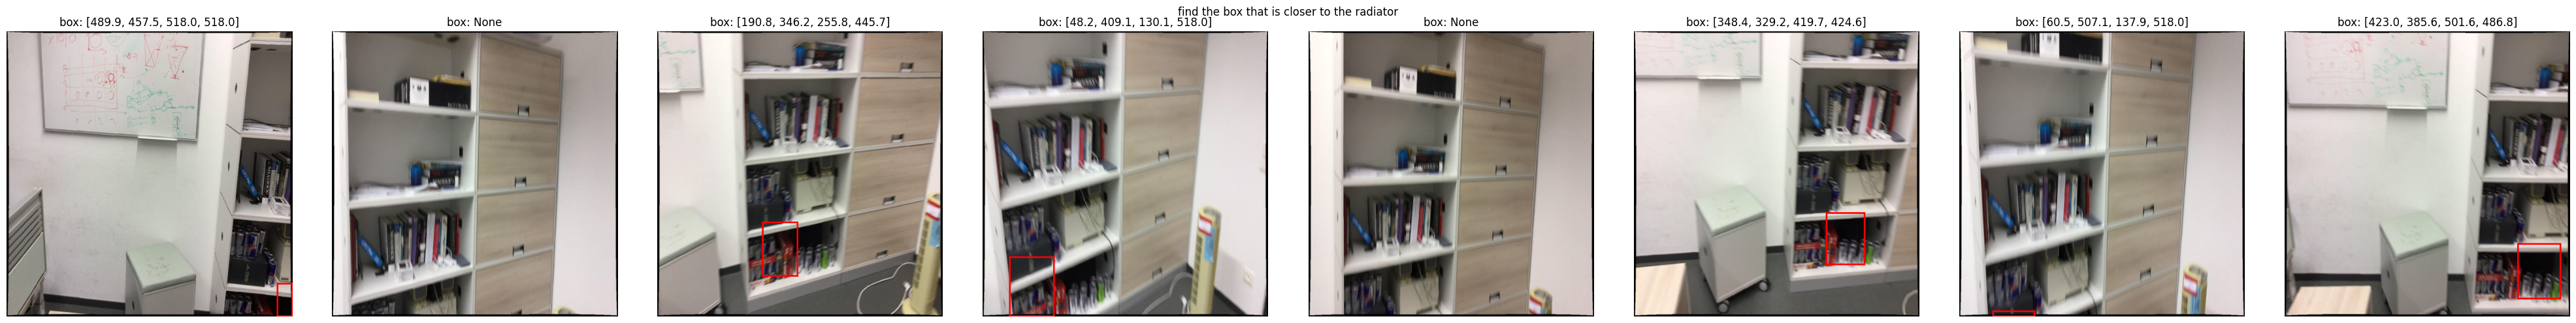

In [5]:
row = random.choice(rows)
print("Query:", row["query"])
print("Images:", len(row["images"]))
print("Boxes:", row["boxes"])

fig, axes = plt.subplots(1, len(row["images"]), figsize=(5*len(row["images"]), 5))
if len(row["images"]) == 1:
      axes = [axes]

for ax, img_path, box in zip(axes, row["images"], row["boxes"]):
      img = Image.open(img_path).convert("RGB")
      img = img.resize((518, 518))
      draw = ImageDraw.Draw(img)
      if box is not None:
          x1, y1, x2, y2 = box
          draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
      ax.imshow(img)
      ax.set_title("box: " + (str([round(v,1) for v in box]) if box else "None"))
      ax.axis("off")

plt.suptitle(row["query"], fontsize=12)
plt.tight_layout()
plt.show()

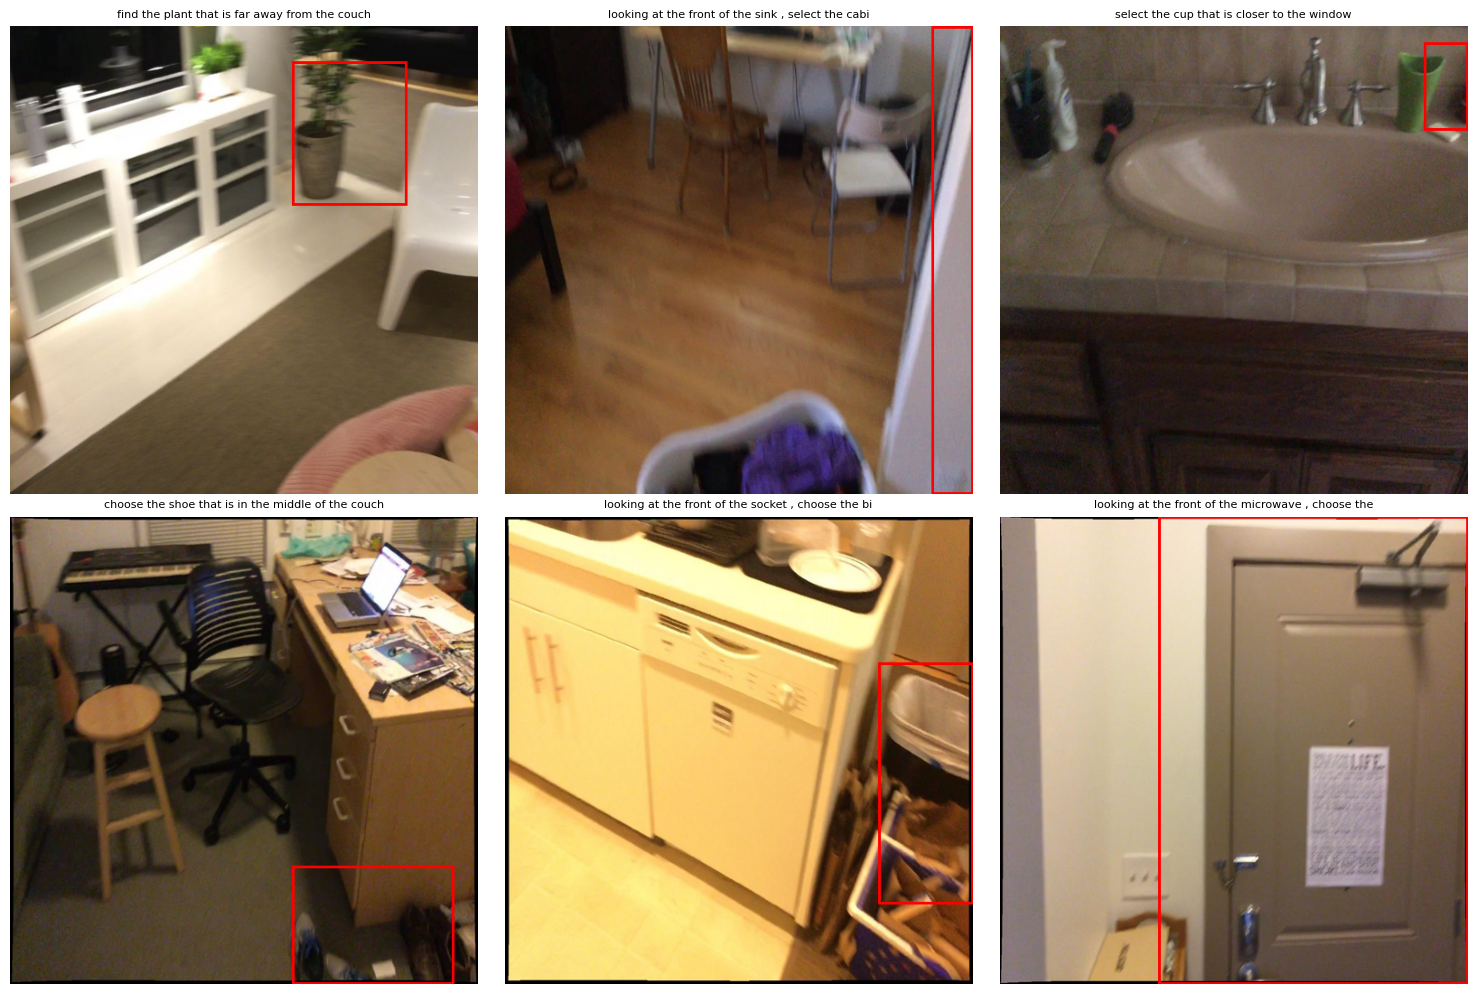

In [3]:
samples = random.sample(rows, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, row in zip(axes.flat, samples):
      for img_path, box in zip(row["images"], row["boxes"]):
          if box is not None:
              img = Image.open(img_path).convert("RGB").resize((518, 518))
              draw = ImageDraw.Draw(img)
              draw.rectangle(box, outline="red", width=3)
              ax.imshow(img)
              ax.set_title(row["query"][:50], fontsize=8)
              ax.axis("off")
              break

plt.tight_layout()
plt.show()

In [4]:
## check if there is some 2d boxes
import json
entries =json.load(open('/glob/g01-cache/pf/Yushuo/vjepa201/source_data/embodiedscan/embodiedscan/embodiedscan_train_vg.json'))
print(entries[0].keys())
print(entries[0])

dict_keys(['scan_id', 'target_id', 'distractor_ids', 'text', 'target', 'anchors', 'anchor_ids', 'tokens_positive'])
{'scan_id': 'scannet/scene0191_00', 'target_id': 5, 'distractor_ids': [6], 'text': 'the board that is beside the door', 'target': 'board', 'anchors': ['door'], 'anchor_ids': [3], 'tokens_positive': [[4, 9]]}


## SPAR-7M jsonl Examination

### Load

In [9]:
import json, random, os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

SPAR_JSON = "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/qa_jsonl/scannet_3229k.json"
SPAR_IMG_ROOT = "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/images"
SPAR_JSONL_ROOT = "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/qa_jsonl"

config = json.load(open(SPAR_JSON))
print(f"Total task types: {len(config)}\n")
print(f"{'Task type':<50} {'#samples':>10}")
print("-" * 62)
for k, v in config.items():
    print(f"{k:<50} {v['length']:>10,}")


Total task types: 50

Task type                                            #samples
--------------------------------------------------------------
obj_spatial_relation_oo_sentence                      116,634
depth_prediction_oc_sentence                          105,066
depth_prediction_oc_fill                              105,066
depth_prediction_oc_select                            105,066
depth_prediction_oo_sentence                           76,837
depth_prediction_oo_fill                               76,837
depth_prediction_oo_select                             66,556
distance_prediction_oc_sentence                       102,526
distance_prediction_oc_fill                           102,526
distance_prediction_oc_select                         102,526
distance_prediction_oo_sentence                        92,742
distance_prediction_oo_fill                            92,742
distance_prediction_oo_select                          92,639
distance_infer_center_oc_sentence              

Task type : distance_prediction_oo
ID        : scene0631_01_29
Q: How far, measured in meters, is the center of book (red point) from the center of shelf (blue point) in the image? Calculate or judge based on the 3D center points of these objects. Answer using a single number and nothing else.
A: 0.9
Images    : ['scene0631_01/image_color/360.jpg']


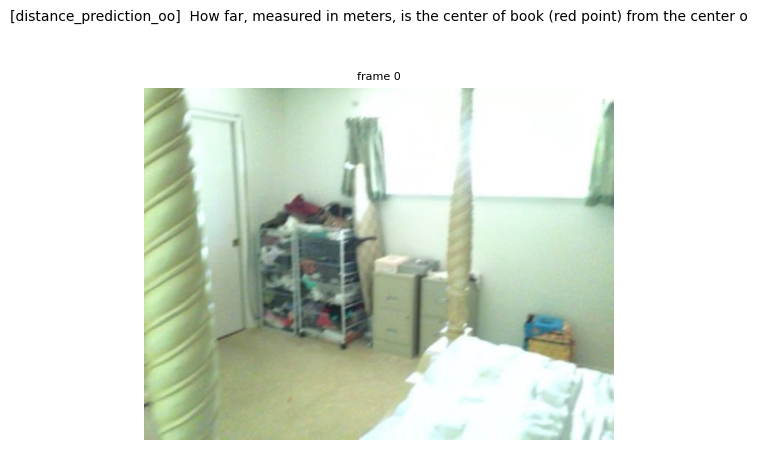

In [10]:
def draw_point(img, xy, color, radius=10):
    draw = ImageDraw.Draw(img)
    x, y = xy
    draw.ellipse([x - radius, y - radius, x + radius, y + radius],
                 fill=color, outline="white", width=2)
    return img

# pick a random task type and load one item from its first jsonl shard
task_name = random.choice(list(config.keys()))
jsonl_rel = config[task_name]["annotation"]   # e.g. "../datasets/scannet_processed/..."
# remap the annotation path to the actual local path
jsonl_filename = os.path.basename(jsonl_rel)
task_subdir    = "/".join(jsonl_rel.split("/")[-4:-1])   # e.g. "train/distance_prediction_oo_mv/sentence"
jsonl_path     = os.path.join(SPAR_JSONL_ROOT, task_subdir, jsonl_filename)

rows = [json.loads(l) for l in open(jsonl_path)]
row  = random.choice(rows)

print(f"Task type : {row['type']}")
print(f"ID        : {row['id']}")
print(f"Q: {row['conversations'][0]['value']}")
print(f"A: {row['conversations'][1]['value']}")
print(f"Images    : {row['image']}")

# determine which frames carry the annotated points (if any)
red_pts   = row.get("red_point",    [])
blue_pts  = row.get("blue_point",   [])
pt_idx    = row.get("point_img_idx", [])  # [[red_img_idx, blue_img_idx], ...]

images_to_show = row["image"][:8]   # cap at 8 for readability
n = len(images_to_show)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for i, (ax, rel_path) in enumerate(zip(axes, images_to_show)):
    full_path = os.path.join(SPAR_IMG_ROOT, rel_path)
    img = Image.open(full_path).convert("RGB")

    # overlay colored dots
    for pair_idx, (rp, bp, pidx) in enumerate(zip(red_pts, blue_pts, pt_idx)):
        r_img_i, b_img_i = pidx
        if i == r_img_i:
            draw_point(img, rp, "red")
        if i == b_img_i:
            draw_point(img, bp, "blue")

    ax.imshow(img)
    ax.set_title(f"frame {i}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"[{row['type']}]  {row['conversations'][0]['value'][:80]}", fontsize=10)
plt.tight_layout()
plt.show()


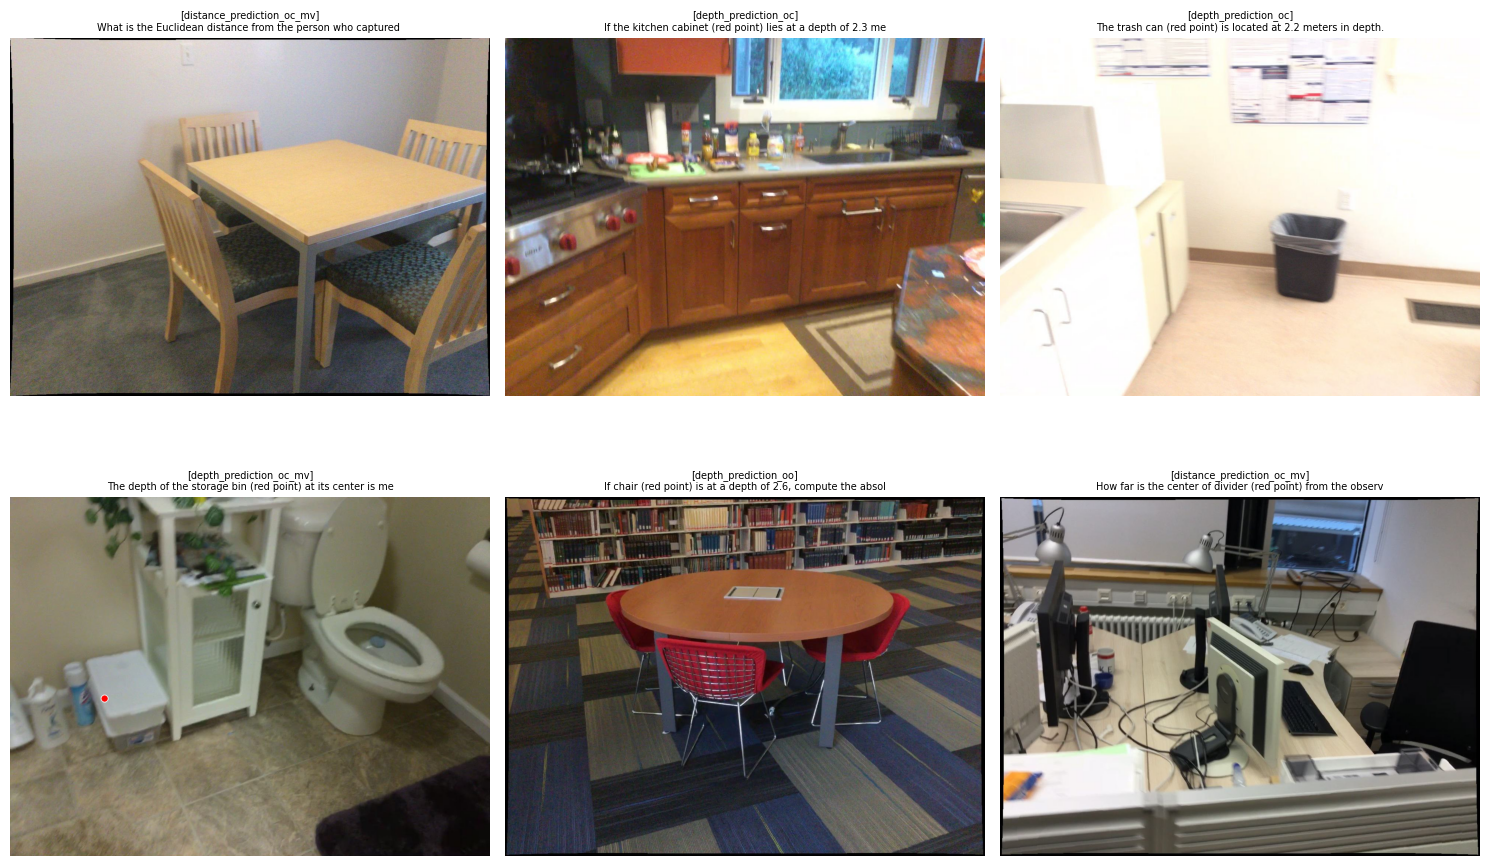

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax in axes.flat:
    task_name = random.choice(list(config.keys()))
    jsonl_rel = config[task_name]["annotation"]
    jsonl_filename = os.path.basename(jsonl_rel)
    task_subdir    = "/".join(jsonl_rel.split("/")[-4:-1])
    jsonl_path     = os.path.join(SPAR_JSONL_ROOT, task_subdir, jsonl_filename)

    rows = [json.loads(l) for l in open(jsonl_path)]
    row  = random.choice(rows)

    red_pts  = row.get("red_point",    [])
    blue_pts = row.get("blue_point",   [])
    pt_idx   = row.get("point_img_idx", [])

    # show the first image that carries an annotated point, or just frame 0
    shown = False
    for pair_idx, (rp, bp, pidx) in enumerate(zip(red_pts, blue_pts, pt_idx)):
        r_i, b_i = pidx
        img_i = r_i  # show the red-point frame
        img = Image.open(os.path.join(SPAR_IMG_ROOT, row["image"][img_i])).convert("RGB")
        draw_point(img, rp, "red")
        draw_point(img, bp, "blue") if b_i == r_i else None
        ax.imshow(img)
        shown = True
        break

    if not shown:
        img = Image.open(os.path.join(SPAR_IMG_ROOT, row["image"][0])).convert("RGB")
        ax.imshow(img)

    ax.set_title(f"[{row['type'][:30]}]\n{row['conversations'][0]['value'][:60]}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Frame-count statistics for converted JSONL files


── embodiedscan_train (336,444 samples) ──
  min=1  max=8  mean=7.70  median=8.0
  frame-count distribution:
      1 frames:    2,631  (  0.8%)  
      2 frames:    3,527  (  1.0%)  
      3 frames:    3,943  (  1.2%)  
      4 frames:    3,452  (  1.0%)  
      5 frames:    4,242  (  1.3%)  
      6 frames:    4,858  (  1.4%)  
      7 frames:    4,835  (  1.4%)  
      8 frames:  308,956  ( 91.8%)  ████████████████████████████████████

── spar_train (11,657,660 samples) ──
  min=4  max=4  mean=4.00  median=4.0
  frame-count distribution:
      4 frames: 11,657,660  (100.0%)  ████████████████████████████████████████

── spar_eval (4,769,873 samples) ──
  min=4  max=4  mean=4.00  median=4.0
  frame-count distribution:
      4 frames: 4,769,873  (100.0%)  ████████████████████████████████████████


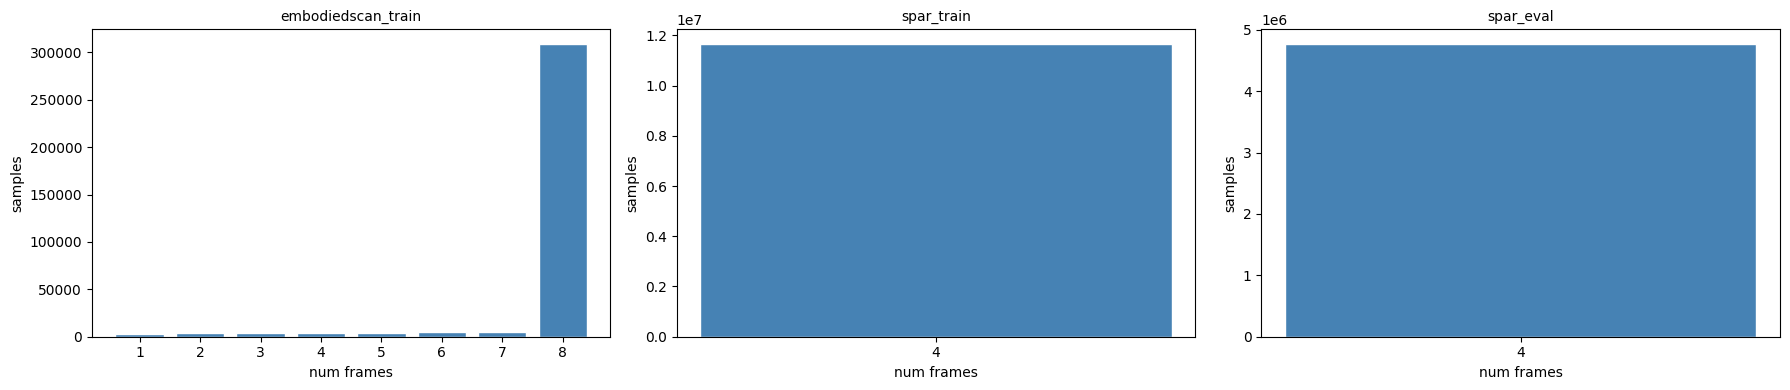

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

JSONL_FILES = {
    "embodiedscan_train":   "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train.jsonl",
    "spar_train":           "/glob/g01-cache/pf/Yushuo/vjepa201/data/spar_sftqa_train.jsonl",
    "spar_eval":            "/glob/g01-cache/pf/Yushuo/vjepa201/data/spar_sftqa_eval.jsonl",
}

def frame_counts(jsonl_path):
    counts = []
    with open(jsonl_path) as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            if "images" in row:
                counts.append(len(row["images"]))
            elif "image" in row:
                counts.append(1)
    return np.array(counts)

stats_all = {}
for name, path in JSONL_FILES.items():
    if not Path(path).exists():
        print(f"[skip] {name}: file not found")
        continue
    counts = frame_counts(path)
    stats_all[name] = counts
    vc = Counter(counts)
    print(f"\n── {name} ({len(counts):,} samples) ──")
    print(f"  min={counts.min()}  max={counts.max()}  mean={counts.mean():.2f}  median={np.median(counts):.1f}")
    print(f"  frame-count distribution:")
    for k in sorted(vc):
        bar = "█" * int(40 * vc[k] / len(counts))
        print(f"    {k:3d} frames: {vc[k]:8,}  ({100*vc[k]/len(counts):5.1f}%)  {bar}")

# histogram
fig, axes = plt.subplots(1, len(stats_all), figsize=(6 * len(stats_all), 4), squeeze=False)
for ax, (name, counts) in zip(axes[0], stats_all.items()):
    bins = range(counts.min(), counts.max() + 2)
    ax.hist(counts, bins=bins, align="left", rwidth=0.8, color="steelblue", edgecolor="white")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("num frames")
    ax.set_ylabel("samples")
    ax.set_xticks(sorted(set(counts)))
plt.tight_layout()
plt.show()


## Data Augmentation in EmboiedScan

In [2]:
import pickle, json, random
ann_dir = '../source_data/embodiedscan/embodiedscan'
data = pickle.load(open(f'{ann_dir}/embodiedscan_infos_train.pkl','rb'))
scan2sample = {s['sample_idx']: s for s in data['data_list'] if s['sample_idx'].startswith('scannet/') and 'cam2img' in s}
print('num scans', len(scan2sample))

vg_path_all = f'{ann_dir}/embodiedscan_train_vg_all.json'
vg = json.load(open(vg_path_all))
print('num vg entries', len(vg))

random.seed(0)
sample_entries = random.sample(vg, min(3000, len(vg)))

pool_sizes = []
visible_sizes = []
for entry in sample_entries:
       scan_id = entry['scan_id']
       target_id = entry['target_id']
       sample = scan2sample.get(scan_id)
       if sample is None: continue
       inst = next((i for i in sample['instances'] if i['bbox_id']==target_id), None)
       if inst is None: continue
       all_views = sample['images']
       visible = [v for v in all_views if target_id in v.get('visible_instance_ids', [])]
       pool = visible if visible else all_views
       pool_sizes.append(len(pool))
       visible_sizes.append(len(visible))

import statistics as st
print('pool size (used for view sampling): mean=%.1f median=%.1f min=%d max=%d' % (st.mean(pool_sizes),st.median(pool_sizes), min(pool_sizes), max(pool_sizes)))
print('visible-only size: mean=%.1f median=%.1f min=%d max=%d, frac visible-empty=%.3f' % (st.mean(visible_sizes),
st.median(visible_sizes), min(visible_sizes), max(visible_sizes), sum(1 for v in visible_sizes if v==0)/len(visible_sizes)))

num scans 958
num vg entries 247468
pool size (used for view sampling): mean=55.4 median=38.0 min=1 max=619
visible-only size: mean=46.7 median=35.0 min=0 max=619, frac visible-empty=0.040


In [3]:
import json, random
import numpy as np

jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train.jsonl"
rows = [json.loads(l) for l in open(jsonl_path)]
print(f"Total rows: {len(rows)}")

Total rows: 336444


## Check eval data

In [2]:
# streaming pass, one line at a time, only keep lightweight stats (mirrors frame_counts above)
import json
from collections import Counter
from pathlib import Path

EVAL_PATH = JSONL_FILES["spar_eval"]

key_counts = Counter()
n_images_counts = Counter()
n_candidates_counts = Counter()
has_target = 0
total = 0

with open(EVAL_PATH) as f:
    for line in f:
        if not line.strip():
            continue
        row = json.loads(line)
        total += 1
        key_counts.update(row.keys())
        n_images_counts[len(row.get("images", row.get("image", []) if isinstance(row.get("image"), list) else [row["image"]] if "image" in row else []))] += 1
        cands = row.get("candidates", row.get("choices", row.get("options", [])))
        if cands:
            n_candidates_counts[len(cands)] += 1
        if any(k in row for k in ("target", "answer", "label")):
            has_target += 1

print(f"total rows: {total}")
print(f"key coverage: {dict(key_counts)}")
print(f"images-per-row: {dict(sorted(n_images_counts.items()))}")
print(f"candidates-per-row: {dict(sorted(n_candidates_counts.items()))}")
print(f"rows with target: {has_target}/{total}")


total rows: 4769873
key coverage: {'images': 4769873, 'query': 4769873, 'candidates': 4769873, 'target': 4769873}
images-per-row: {4: 4769873}
candidates-per-row: {2: 411943, 4: 4357930}
rows with target: 4769873/4769873


In [3]:
# spot-check first N image paths actually exist on disk, streaming (stop early, don't scan whole file)
N_CHECK = 200
missing = 0
checked = 0
with open(EVAL_PATH) as f:
    for line in f:
        if checked >= N_CHECK:
            break
        if not line.strip():
            continue
        row = json.loads(line)
        imgs = row.get("images") or [row.get("image")]
        for p in imgs:
            checked += 1
            if not Path(p).exists():
                missing += 1

print(f"checked {checked} image paths, missing {missing}")


checked 200 image paths, missing 0


In [8]:
# one sample row only, no full-file load
with open(EVAL_PATH) as f:
    sample_row = json.loads(f.readline())
print(json.dumps(sample_row, ensure_ascii=False, indent=2)[:800])


{
  "images": [
    "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/images/scene0649_00/image_color/985.jpg",
    "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/images/scene0649_00/image_color/1089.jpg",
    "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/images/scene0649_00/image_color/985.jpg",
    "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/images/scene0649_00/image_color/1089.jpg"
  ],
  "query": "Locate the observer from the second image within the coordinate frame of the first image. Give 2D image-plane coordinates and depth in meters. Pick the right response from the available choices.",
  "candidates": [
    "Image Coor:(304, 745), Depth:0.8 meters",
    "Image Coor:(519, 359), Depth:0.8 meters",
    "Image Coor:(545, 470), D
